The notebooks so far have assumed that we've already downloaded data from a seismic data centre.  But if we plan to look anywhere new or look at more LFEs, we'll have to download data.

In [20]:
import numpy as np
import obspy
import os
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Pick a region and a set of stations

First, we have to decide where to look.  Let's try looking at some LFEs along the Mexican subduction zone, near Guerrero.

There were a bunch of stations installed here from 2005 to 2007, in what was called the MASE array.  You can see their locations here: https://ds.iris.edu/gmap/#network=TO&maxlat=24.0096&maxlon=-97.6445&minlat=15.8768&minlon=-100.3362&drawingmode=box&planet=earth.

These data are stored by the IRIS data centre, and we can figure out the station names and channels by querying the data server.



In [2]:
# this line creates a shortcut to the function obspy.clients.fdsn.client.Client
from obspy.clients.fdsn.client import Client

# and this line calls the function Client to establish a connection to IRIS.
# note you might also try "ORFEUS" or "GEOFON" if you were looking for data collected by Europeans, 
# though IRIS has lots of European data too
client = Client("IRIS")

In [5]:
# let's grab an inventory of stations
# note that here we specify channels of the form '?H?', so we get seismic data
inv=client.get_stations(minlongitude=-101,maxlongitude=-97.6,
                        minlatitude=15,maxlatitude=24,
                        network='TO',channel='HH?',
                        level='channel',includeavailability=True)

In [7]:
# the inventory is indexed first by network (we've asked only for TO)
# then by station, then by channel

# we could look at the stations in just one network
print(inv[0])

Network TO (Tectonic Observatory - MASE, VEOX , PeruSE, CCSE (MASE, VEOX, PERUSE, CCSE))
	Station Count: 101/340 (Selected/Total)
	2004-01-01T00:00:00.000000Z - --
	Access: open
	Contains:
		Stations (101):
			TO.ACAH (MASE station ACAH, , , )
			TO.ACAP (MASE station ACAP, , , )
			TO.AGBE (MASE station AGBE, , , )
			TO.AMAC (MASE station AMAC, , , )
			TO.AMAR (MASE station AMAR, , , )
			TO.APOT (MASE station APOT, , , )
			TO.ARBO (MASE station ARBO, , , )
			TO.ATLA (MASE station ATLA, , , )
			TO.ATOT (MASE station ATOT, , , )
			TO.BUCU (MASE station BUCU, , , )
			TO.CANT (MASE station CANT, , , )
			TO.CARR (MASE station CARR, , , )
			TO.CASA (MASE station CASA, , , )
			TO.CEME (MASE station CEME, , , )
			TO.CHIC (MASE station CHIC, , , )
			TO.CHIO (MASE station CHIO, , , )
			TO.CIEN (MASE station CIEN, , , )
			TO.CIRE (MASE station CIRE, , , )
			TO.CIRI (MASE station CIRI, , , )
			TO.COAC (MASE station COAC, , , )
			TO.CUCE (MASE station CUCE, , , )
			TO.CUNO (MASE

In [8]:
# and maybe the first station in that network
print(inv[0][0])

# and the first channel at the station
print(inv[0][0][0])

Station ACAH (MASE station ACAH, , , )
	Station Code: ACAH
	Channel Count: 6/6 (Selected/Total)
	2004-12-15T00:00:00.000000Z - 2007-06-09T00:00:00.000000Z
	Access: open 
	Latitude: 17.3621, Longitude: -99.4683, Elevation: 838.0 m
	Available Channels:
	    ..HH[ZNE]   100.0 Hz  2004-12-15 to 2007-06-09
	  .01.HH[ZNE]   100.0 Hz  2004-12-15 to 2007-06-09

Channel 'HHE', Location '' 
	Time range: 2004-12-15T00:00:00.000000Z - 2007-06-09T00:00:00.000000Z
	Latitude: 17.3621, Longitude: -99.4683, Elevation: 838.0 m, Local Depth: 0.0 m
	Azimuth: 90.00 degrees from north, clockwise
	Dip: 0.00 degrees down from horizontal
	Channel types: GEOPHYSICAL
	Sampling Rate: 100.00 Hz
	Sensor (Description): None (CMG-3T)
	Response information available


In [10]:
# for now, we just want a list of the available stations
stations=np.unique([stat.code for stat in inv[0]])
print(stations)

['ACAH' 'ACAP' 'AGBE' 'AMAC' 'AMAR' 'APOT' 'ARBO' 'ATLA' 'ATOT' 'BUCU'
 'CANT' 'CARR' 'CASA' 'CEME' 'CHIC' 'CHIO' 'CIEN' 'CIRE' 'CIRI' 'COAC'
 'CUCE' 'CUNO' 'ECID' 'EL30' 'EL40' 'ELBA' 'ELPA' 'ELPO' 'ESTA' 'HUEJ'
 'HUIT' 'IXCA' 'JIUT' 'KM67' 'MAXE' 'MAZA' 'MIMO' 'MIXC' 'MOJO' 'MOLA'
 'MULU' 'NOGA' 'OCOL' 'OCOT' 'PABL' 'PACH' 'PALM' 'PASU' 'PEMU' 'PETA'
 'PLAT' 'PLAY' 'PLLI' 'PLSA' 'PSIQ' 'PTCU' 'PTRP' 'PUIX' 'QUEM' 'RIVI'
 'RODE' 'SABI' 'SAFE' 'SAFR' 'SAGR' 'SALU' 'SAME' 'SAPA' 'SAPE' 'SATA'
 'SJVH' 'SNLU' 'SUPA' 'TECA' 'TEMI' 'TEMP' 'TEPE' 'TEPO' 'TIAG' 'TIAN'
 'TIBL' 'TICO' 'TIZA' 'TLAL' 'TOMA' 'TONA' 'TONI' 'TONN' 'TONO' 'TOSU'
 'UICA' 'VEGU' 'VENA' 'VEVI' 'VLAD' 'XALI' 'XALT' 'XOCH' 'XOLA' 'ZACA'
 'ZURI']


### 2. Read the regional LFE catalogue

Other researchers, particularly Frank et al (2014), have identified a number of LFEs during SSEs in Guerrero.  Our LFE analysis object has a function to read in Frank et al's catalogue: read_detection_info_guerrero.

So let's read them.

In [23]:
# create an analysis object
data_directory=os.path.join(os.environ['DATA'],'LFEAnalysis')
lf=lfeanalysis.lfanalyse(fnum=879,data_directory=data_directory,region='Guerrero')

# read the relevant detections
lf.read_detection_info()

[ 335  413  196 ...  879  811 1018]


[ 335  413  196 ...  879  811 1018]


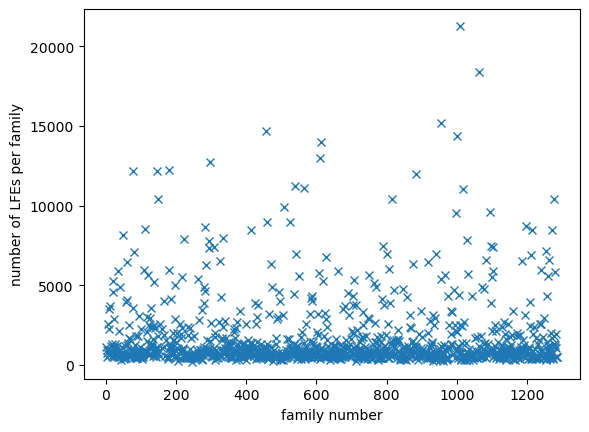

In [24]:
# if we want to see all the available families,
# it may be useful to read the whole catalog
import read_catalogues
reload(read_catalogues)
tms,loc,dct=read_catalogues.read_frank2014(data_directory=data_directory)
iev=dct['Template_ID'].astype(int)

# the family of each LFE detection
print(iev)

# number of LFEs per family
nper=np.bincount(iev)
fnums=np.where(nper>0)[0]
nper=nper[fnums]
plt.plot(fnums,nper,linestyle='none',marker='x');
plt.xlabel('family number');
plt.ylabel('number of LFEs per family');

In [25]:
# check out the detections we have here
print(lf.tms)

print('\nFamily {:d} has {:d} detected LFEs'.format(lf.fnum,lf.tms.size))

[UTCDateTime(2005, 1, 16, 3, 24, 24, 900000)
 UTCDateTime(2005, 1, 16, 14, 41, 26, 300000)
 UTCDateTime(2005, 1, 17, 3, 0, 4) ...
 UTCDateTime(2007, 4, 14, 21, 5, 32, 700000)
 UTCDateTime(2007, 4, 15, 16, 51, 35, 500000)
 UTCDateTime(2007, 4, 15, 23, 47, 47, 700000)]

Family 879 has 1169 detected LFEs


### 3. Identify the channels for each of the available stations

In [63]:
# note the stations of interest, as identified above
lf.stns=stations.copy()

# identify the channels
# for Guerrero, we know that the channels all start with H,
# so specify that
lf.identify_channels(cdes='H')


Identified channels for 101 of 101 stations


In [64]:
# we can now see which channels are available
print(lf.channels)

stn='ATOT'
print('\nThe channels for station {:s} are '.format(stn),lf.channels[stn])

{'ACAH': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'ACAP': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'AGBE': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'AMAC': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'AMAR': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'APOT': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'ARBO': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'ATLA': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'ATOT': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'BUCU': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CANT': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CARR': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CASA': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CEME': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CHIC': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CHIO': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CIEN': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CIRE': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'CIRI': array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), 'COAC': array(['HHE', 'HHN', '

### 4. Try to start downloading the data

We'll use an FDSN client to retrieve data from the IRIS data centre.  The code is set up to download intervals of data that include the LFE detection times.  Each interval is lf.tlen seconds long, and the detection times are a quarter of the way through the interval.

In [104]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=540,region='Guerrero',lfi=lf)

print('Downloading and processing {:0.0f}-s data segments'.format(lf.tlen))

print('\nThe data will be saved in directory {:s}'.format(lf.directory()))


The data will be saved in directory /home/earthquakes2/homes/Jess/DATA/LFEFocMech/Guerrero/Family540


In [106]:
# download the data for the first 4 events
lf.download_data(max_events=4)

# these data should be saved in directory lf.directory()

ONLY DOWNLOADING THE FIRST 4 EVENTS


/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


Writing to file and continuing


This will take a while---perhaps even 30 seconds to a minute per event.  The analysis downloads the data, removes the instrumental response, and saves the resulting seismograms.

### 5. Check that the data retrieval is okay

We can now read in the data from these five events and see how things are looking.

In [107]:
# create a new analysis object
reload(lfeanalysis)
lf2=lfeanalysis.lfanalyse(fnum=540,region='Guerrero')

In [108]:
# read detection info and templates                                                             
lf2.read_detection_info()

In [109]:
# read the data                                                
lf2.read_data()

In [110]:
print(lf2.data)

{'ACAH.HHE': array([[ 9.24311527e-08,  1.49252686e-07,  1.32050622e-07,
        -2.82554698e-07],
       [ 3.44524639e-08,  2.39514255e-07,  1.11459981e-07,
        -2.76684711e-07],
       [-8.00424518e-09,  2.80069734e-07,  6.81448508e-08,
        -2.37886253e-07],
       ...,
       [ 1.88566341e-07,  7.05488977e-08,  2.06113631e-07,
         1.18678387e-07],
       [ 1.57748871e-07,  1.64770366e-07,  2.09686576e-07,
        -1.81840223e-07],
       [ 4.38289399e-08,  1.86270803e-07,  1.67433212e-07,
        -4.54161593e-07]]), 'ACAH.HHN': array([[ 1.73716997e-07,  2.29610436e-07, -1.04659532e-07,
        -2.56143061e-07],
       [ 1.43580414e-07,  2.73438270e-07, -1.48826751e-07,
        -1.82191380e-07],
       [ 2.07161299e-07,  2.59916339e-07, -1.31326884e-07,
        -1.46585277e-07],
       ...,
       [-5.99222587e-07,  2.30827377e-07, -5.34955255e-08,
         1.02857453e-07],
       [-3.65465523e-07,  1.96624679e-07,  3.97205566e-08,
         1.17549971e-07],
       [ 4.372

These seismograms are for intervals  [0 1 2 3]


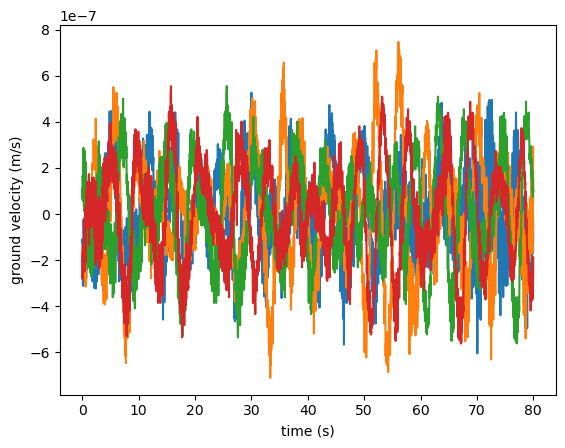

In [111]:
# data for station AMAC, channel HHN
data = lf2.data['AMAC.HHN']
plt.plot(np.arange(0,data.shape[0])/lf2.sampling_rate,data);
plt.ylabel('ground velocity (m/s)');
plt.xlabel('time (s)');

print('These seismograms are for intervals ',lf2.ev['AMAC.HHN'])

### 6.  Download all of the data

If everything seems okay with the first four events, we can move on.

- First we delete everything in the data directory for this family: whatever is in lf.directory()

- Then we download everything

In [ ]:
# uncomment and run to download it all
#lf.download_data()